# Import and Model Loading:

In [1]:
import sys
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from xray.interpretability import *

c:\Users\megha\Desktop\xray-transformers\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
import importlib
import xray.evaluation as evaluation

evaluation = importlib.reload(evaluation)

In [3]:
from inspect import getmembers, isfunction

# Get all members that satisfy the 'isfunction' condition
functions_list = getmembers(evaluation, isfunction)

# Print just the names of the functions
for name, func in functions_list:
    # Optional: skip private/dunder functions
    #if not name.startswith('_'):
        print(name + '()')


TypedDict()
_create_deleted_input()
_get_word_token_groups()
_predict_from_ids()
evaluate_example()
evaluate_probability_faithfulness()
evaluate_repeated_random_faithfulness()
logit_to_probability()
predict_target_logit()
print_faithfulness_summary()
random_deletion_curve()
repeated_random_deletion_curves()
summarize_random_curves()
top_k_deletion_curve()


In [4]:
#IMPORTS:

import torch
import matplotlib.pyplot as plt

from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer
)

from xray.interpretability import DistilBertInterpreter

# LOAD THE HUGGINGFACE MODEL:

# Use GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model = DistilBertForSequenceClassification.from_pretrained(
    "JDsouza1/distilbert-imdb-sentiment"
).to(device)

tokenizer = DistilBertTokenizer.from_pretrained(
    "JDsouza1/distilbert-imdb-sentiment"
)

print("Model loaded!")

Device: cpu


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1460.89it/s]


Model loaded!


In [5]:
interpreter = DistilBertInterpreter(
    model=model,
    tokenizer=tokenizer,
    device=device
)

# Testing with one sentence:

In [9]:
test_text = "This was not a bad movie at all"

attribution_result = interpreter.attribute(test_text)

tokens = attribution_result["tokens"]
token_attributions = attribution_result["token_attributions"]
convergence_delta = attribution_result["convergence_delta"]
input_output = attribution_result["input_output"]
baseline_output = attribution_result["baseline_output"]
total_attribution = attribution_result["total_attribution"]
completeness_error = attribution_result["completeness_error"]

In [7]:
with torch.no_grad():
    encoding = tokenizer(
        test_text,
        return_tensors="pt",
        truncation=True,
        padding=False
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    target_label = torch.argmax(
        outputs.logits,
        dim=1
    ).item()

print("Target label:", target_label)
print("Target logit:", input_output.item())

Target label: 1
Target logit: 0.7795644998550415


Aggregate token attributions:

In [11]:
words, word_scores = interpreter.aggregate_tokens(
    tokens,
    token_attributions
)

print("Word-level attributions:")

for word, score in zip(words, word_scores):
    print(f"{word:15} {float(score):+.4f}")

Word-level attributions:
this            +0.2466
was             +0.2090
not             +0.5315
a               +0.5419
bad             -0.4694
movie           -0.5103
at              +0.1927
all             -0.0304


# Attribution-guided deletion curve:

In [13]:
import inspect
from xray.evaluation import top_k_deletion_curve

print(inspect.signature(top_k_deletion_curve))

(model: torch.nn.modules.module.Module, tokenizer: Any, text: str, scores: numpy.ndarray, target_label: int, device: torch.device) -> xray.evaluation.DeletionCurve


In [22]:
from xray.evaluation import top_k_deletion_curve

top_k_curve = top_k_deletion_curve(
    model=model,
    tokenizer=tokenizer,
    text=test_text,
    scores=np.asarray(word_scores),
    target_label=target_label,
    device=device,
)

In [23]:
# Inspect:
print("Fractions:")
print(top_k_curve["fractions"])

print("\nTarget logits:")
print(top_k_curve["logits"])

Fractions:
[0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0]

Target logits:
[0.653679370880127, 0.2926931083202362, -2.66717267036438, -2.246964693069458, -1.1101876497268677, -0.7327213883399963, -0.44897225499153137, -0.010651255957782269, -0.030771732330322266]


# Random Baseline:

In [29]:
from xray.evaluation import random_deletion_curve

random_curve = random_deletion_curve(
    model=model,
    tokenizer=tokenizer,
    text=test_text,
    target_label=target_label,
    device=device,
    seed=42
)

In [30]:
# Inspect:
print("Fractions:")
print(random_curve["fractions"])

print("\nRandom deletion logits:")
print(random_curve["logits"])

Fractions:
[0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0]

Random deletion logits:
[0.653679370880127, 0.2926931083202362, -2.1621296405792236, -1.5901036262512207, 0.016108114272356033, -0.5189729928970337, 0.12416292726993561, -0.07643508911132812, -0.030771732330322266]


# Compare Attribution-guided deletion curve vs Random Baseline:
top-k vs random

# Visualizing curves:

We're looking for whether the attribution-guided curve generally rises faster/earlier than the random curve.
If that behavior is observed, it visually supports the AUC result.


**Raw logit deletion curve:**

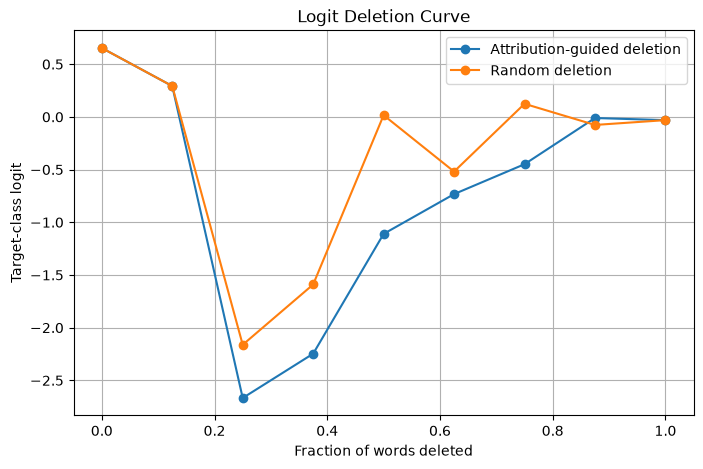

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    top_k_curve["fractions"],
    top_k_curve["logits"],
    marker="o",
    label="Attribution-guided deletion"
)

plt.plot(
    random_curve["fractions"],
    random_curve["logits"],
    marker="o",
    label="Random deletion"
)

plt.xlabel("Fraction of words deleted")
plt.ylabel("Target-class logit")
plt.title("Logit Deletion Curve")

plt.legend()
plt.grid(True)

plt.show()

**Cumulative drop:**

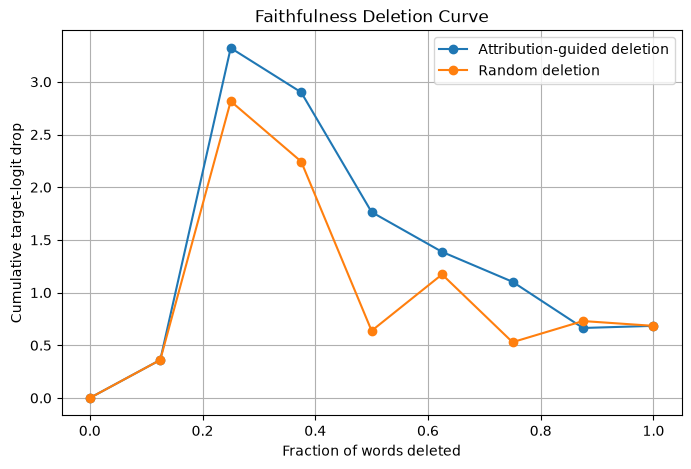

In [34]:
original_logit = top_k_curve["original_logit"]

top_k_drop = [
    original_logit - logit
    for logit in top_k_curve["logits"]
]

random_drop = [
    original_logit - logit
    for logit in random_curve["logits"]
]

plt.figure(figsize=(8, 5))

plt.plot(
    top_k_curve["fractions"],
    top_k_drop,
    marker="o",
    label="Attribution-guided deletion"
)

plt.plot(
    random_curve["fractions"],
    random_drop,
    marker="o",
    label="Random deletion"
)

plt.xlabel("Fraction of words deleted")
plt.ylabel("Cumulative target-logit drop")
plt.title("Faithfulness Deletion Curve")

plt.legend()
plt.grid(True)

plt.show()

In [35]:
print("top_k_curve logits")
print(top_k_curve["logits"])
print("random_curve logits")
print(random_curve["logits"])

top_k_curve logits
[0.653679370880127, 0.2926931083202362, -2.66717267036438, -2.246964693069458, -1.1101876497268677, -0.7327213883399963, -0.44897225499153137, -0.010651255957782269, -0.030771732330322266]
random_curve logits
[0.653679370880127, 0.2926931083202362, -2.1621296405792236, -1.5901036262512207, 0.016108114272356033, -0.5189729928970337, 0.12416292726993561, -0.07643508911132812, -0.030771732330322266]


The important observation is that both curves behave non-monotonically. That's not necessarily a bug.
Deleting a word can cause the model's target logit to:
decrease,
increase,
cross zero,
decrease again.
For a nonlinear Transformer, that's completely possible.

Look at step 2:
Top-k:   -2.6672
Random:  -2.1621

The attribution-guided deletion has pushed the target logit substantially lower than random deletion at this point.

That is consistent with the AUC result:

Top-k drop AUC:   1.4802
Random drop AUC:  1.1041

So the single-example experiment is internally consistent.

But there is another issue.

Look at step 1:

Top-k:   0.292693
Random:  0.292693

They are exactly identical.

Random deletion and attribution-guided deletion shouldn't necessarily remove the same first word.

This suggests the random ordering may have selected the same first word as the attribution ranking.

That can happen by chance, especially with a short sentence, but it is best to inspect the actual deletion order.

In [36]:
print("Words:")
for i, word in enumerate(top_k_curve["words"]):
    print(i, word)

print("\nAttribution scores:")
for word, score in zip(words, word_scores):
    print(f"{word:15} {float(score):+.4f}")

Words:
0 this
1 was
2 not
3 a
4 bad
5 movie
6 at
7 all

Attribution scores:
this            +0.2466
was             +0.2090
not             +0.5315
a               +0.5419
bad             -0.4694
movie           -0.5103
at              +0.1927
all             -0.0304


Inspect the random order:

In [37]:
rng = np.random.default_rng(42)

random_order = np.arange(len(words))
rng.shuffle(random_order)

print("Random deletion order:")
for step, index in enumerate(random_order, start=1):
    print(step, words[index])

Random deletion order:
1 a
2 bad
3 not
4 all
5 at
6 was
7 movie
8 this


For Attribution order:

In [38]:
attribution_order = np.argsort(
    -np.abs(
        np.asarray(
            [float(score) for score in word_scores]
        )
    )
)

print("Attribution deletion order:")
for step, index in enumerate(attribution_order, start=1):
    print(step, words[index])

Attribution deletion order:
1 a
2 not
3 movie
4 bad
5 this
6 was
7 at
8 all


So the identical first deletion is simply because both orderings happened to select 'a' first with this particular seed. There is no implementation issue there.

Pipeline:

DistilBERT -> Integrated Gradients -> Token attributions -> Word-level aggregation -> Attribution ranking
 -> Token-preserving deletion
 -> Target-logit curve
 -> Random deletion baseline
 -> Cumulative-drop AUC


# Multiple curves:

In [42]:
from xray.evaluation import repeated_random_deletion_curves

seeds = [1, 2, 3, 4, 5]

random_curves = repeated_random_deletion_curves(
    model=model,
    tokenizer=tokenizer,
    text=test_text,
    target_label=target_label,
    device=device,
    seeds=seeds
)

In [43]:
print("Number of random curves:", len(random_curves))

for i, curve in enumerate(random_curves):
    print(
        f"Seed {seeds[i]}:",
        curve["logits"]
    )

Number of random curves: 5
Seed 1: [0.653679370880127, 0.518320620059967, 0.414243221282959, 0.25732770562171936, -0.9893425107002258, -0.6825655102729797, -0.14609599113464355, -0.010651255957782269, -0.030771732330322266]
Seed 2: [0.653679370880127, 0.3306431174278259, 0.20781174302101135, -0.10842801630496979, -2.1992368698120117, -1.7795687913894653, -0.24922433495521545, -0.34037724137306213, -0.030771732330322266]
Seed 3: [0.653679370880127, 0.3306431174278259, 0.470081627368927, -2.5525898933410645, -2.679795980453491, -0.08361679315567017, -0.15277273952960968, -0.07643508911132812, -0.030771732330322266]
Seed 4: [0.653679370880127, 0.10029073059558868, -2.7053439617156982, -2.189845085144043, -2.1564531326293945, 0.054012756794691086, -0.2685668170452118, -0.06295072287321091, -0.030771732330322266]
Seed 5: [0.653679370880127, 0.10029073059558868, -1.8420608043670654, -1.2967134714126587, -1.7615447044372559, 0.2983969748020172, -0.20171873271465302, -0.07643508911132812, -0.0

In [44]:
from xray.evaluation import summarize_random_curves

random_summary = summarize_random_curves(
    random_curves
)

print("Mean random logits:")
print(random_summary["mean_logits"])

print("\nRandom logit standard deviation:")
print(random_summary["std_logits"])

Mean random logits:
[ 0.65367937  0.27603766 -0.69105363 -1.17804975 -1.95727464 -0.43866827
 -0.20367572 -0.11336988 -0.03077173]

Random logit standard deviation:
[0.         0.15902107 1.32363577 1.10739068 0.56488188 0.74425283
 0.04938805 0.1160637  0.        ]


Instead of:
- The attribution curve beat random seed 42.

Conclusion:
- The attribution-guided deletion curve was compared against the mean of five independently randomized deletion curves, with variability reported across random trials.


Attribution vs mean random plot:

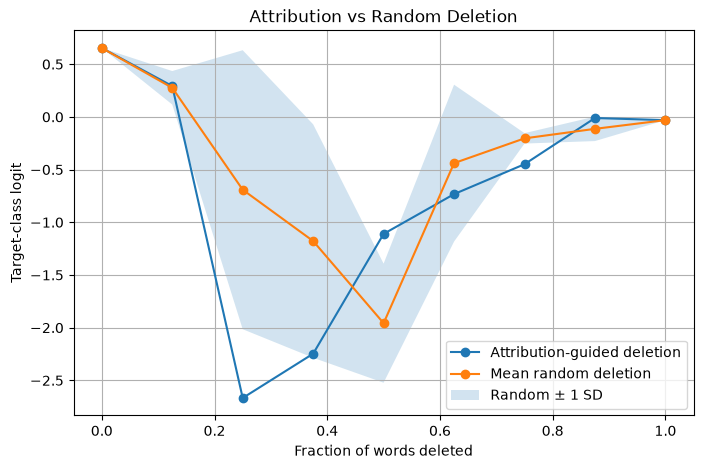

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    top_k_curve["fractions"],
    top_k_curve["logits"],
    marker="o",
    label="Attribution-guided deletion"
)

plt.plot(
    random_summary["fractions"],
    random_summary["mean_logits"],
    marker="o",
    label="Mean random deletion"
)

plt.fill_between(
    random_summary["fractions"],
    random_summary["mean_logits"] -
    random_summary["std_logits"],
    random_summary["mean_logits"] +
    random_summary["std_logits"],
    alpha=0.2,
    label="Random ± 1 SD"
)

plt.xlabel("Fraction of words deleted")
plt.ylabel("Target-class logit")
plt.title("Attribution vs Random Deletion")
plt.legend()
plt.grid(True)

plt.show()

This gives three things:
- Attribution-guided curve
- Mean random curve
- Random variability band

In [46]:
print("Mean random logits:")
print(random_summary["mean_logits"])
print("Random logits std: ")
print(random_summary["std_logits"])

Mean random logits:
[ 0.65367937  0.27603766 -0.69105363 -1.17804975 -1.95727464 -0.43866827
 -0.20367572 -0.11336988 -0.03077173]
Random logits std: 
[0.         0.15902107 1.32363577 1.10739068 0.56488188 0.74425283
 0.04938805 0.1160637  0.        ]


Observation: 
- The random baseline has substantial variability, especially around 25–50% deletion. That's exactly why using several random seeds is preferable to relying on one random deletion order.

The attribution-guided curve is:

- [ 0.6537, 0.2927, -2.6672, -2.2470, -1.1102, -0.7327,
 -0.4490, -0.0107, -0.0308]

- So now there is a useful comparison between one attribution-guided curve and the mean ± standard deviation of multiple random curves.


# Compare attribution against the repeated random baseline (Multiple curves):

In [47]:
from xray.evaluation import evaluate_repeated_random_faithfulness
faithfulness_summary = evaluate_repeated_random_faithfulness(
    top_k_curve=top_k_curve,
    random_summary=random_summary
)

for key, value in faithfulness_summary.items():
    print(f"{key}: {value}")

original_logit: 0.653679370880127
top_k_final_logit: -0.030771732330322266
random_mean_final_logit: -0.030771732330322266
top_k_final_drop: 0.6844511032104492
random_mean_final_drop: 0.6844511032104492
top_k_drop_auc: 1.4802447439869866
random_mean_drop_auc: 1.153004423319362
top_k_auc_higher: True


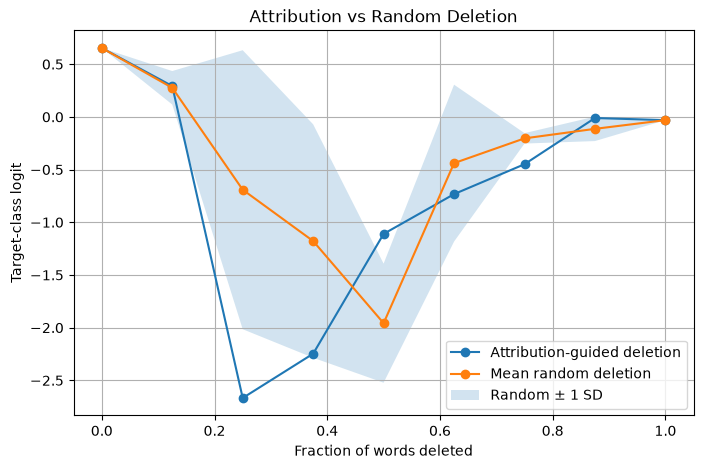

In [48]:
plt.figure(figsize=(8, 5))

# Attribution-guided deletion
plt.plot(
    top_k_curve["fractions"],
    top_k_curve["logits"],
    marker="o",
    label="Attribution-guided deletion"
)

# Mean random deletion
plt.plot(
    random_summary["fractions"],
    random_summary["mean_logits"],
    marker="o",
    label="Mean random deletion"
)

# Random variability
plt.fill_between(
    random_summary["fractions"],
    random_summary["mean_logits"] -
    random_summary["std_logits"],
    random_summary["mean_logits"] +
    random_summary["std_logits"],
    alpha=0.2,
    label="Random ± 1 SD"
)

plt.xlabel("Fraction of words deleted")
plt.ylabel("Target-class logit")
plt.title("Attribution vs Random Deletion")
plt.legend()
plt.grid(True)

plt.show()

In the current example, the attribution curve drops much more strongly during the early deletion steps, while the random baseline has considerable variability.

SUMMARY:

In [49]:
from xray.evaluation import print_faithfulness_summary

print_faithfulness_summary(
    faithfulness_summary
)


FAITHFULNESS EVALUATION
----------------------------------------
Original target logit:       0.6537
Attribution final logit:     -0.0308
Mean random final logit:     -0.0308

Attribution drop AUC:        1.4802
Mean random drop AUC:        1.1530

Attribution AUC > random:   True


# Multiple examples (seeds):

In [55]:
import importlib
import xray.evaluation as evaluation

evaluation = importlib.reload(evaluation)

In [56]:
from xray.evaluation import evaluate_example

In [57]:
seeds = [1, 2, 3, 4, 5]

result = evaluate_example(
    model=model,
    tokenizer=tokenizer,
    interpreter=interpreter,
    text="This was not a bad movie at all.",
    device=device,
    seeds=seeds
)

This single call now replaces the previous sequence of:
attribute() -> aggregate_tokens() -> top_k_deletion_curve() -> random_deletion_curve() × 5
 -> summarize_random_curves() -> evaluate_repeated_random_faithfulness()

**So run this single function instead of all the above**

In [58]:
print("Text:", result["text"])
print("Target label:", result["target_label"])

print("=" * 40)

print("\nWords and attributions:")

for word, score in zip(
    result["words"],
    result["word_scores"]
):
    print(f"{word:15} {float(score):+.4f}")

print("=" * 40)

print(
    "\nCompleteness error:",
    float(result["completeness_error"])
)

print("=" * 40)

print_faithfulness_summary(
    result["faithfulness"]
)

Text: This was not a bad movie at all.
Target label: 1

Words and attributions:
this            +0.1083
was             +0.3115
not             +0.6287
a               +0.5776
bad             -0.4222
movie           -0.3839
at              -0.0002
all             -0.2195
.               +0.2654

Completeness error: -0.010863780975341797

FAITHFULNESS EVALUATION
----------------------------------------
Original target logit:       0.6761
Attribution final logit:     -0.0308
Mean random final logit:     -0.0308

Attribution drop AUC:        1.8351
Mean random drop AUC:        1.5628

Attribution AUC > random:   True


In [59]:
print("Result top k curve logits:")
print(
    result["top_k_curve"]["logits"]
)
print("\nMean logits random summary:")
print(
    result["random_summary"]["mean_logits"]
)

Result top k curve logits:
[0.6761478185653687, -2.666501760482788, -2.6824147701263428, -1.8876984119415283, -1.1412630081176758, -1.2830487489700317, -0.8280239105224609, -0.20171873271465302, -0.06295072287321091, -0.030771732330322266]

Mean logits random summary:
[ 0.67614782 -0.39437531 -0.98854199 -2.02824023 -2.13715329 -1.21569008
 -0.85479153 -0.52825891 -0.15517298 -0.03077173]


# Dataset level evaluation:

In [60]:
test_texts = [
    "This was not a bad movie at all.",
    "The movie looked amazing but the story was painfully boring.",
    "I expected this movie to be terrible, but it was actually wonderful.",
    "The acting was good, but everything else was disappointing.",
    "I really wanted to like this movie, but unfortunately it was awful.",
    "This movie was absolutely fantastic and I loved every minute of it.",
    "The film was boring and predictable from beginning to end.",
    "The performances were excellent and the story was engaging.",
    "I would not recommend this movie to anyone.",
    "Despite some flaws, this was an enjoyable movie."
]

print("Number of test examples:", len(test_texts))

Number of test examples: 10


- Deliberately included mixed, negative, positive, and negation-heavy sentences. 
- That is useful for testing whether the attribution method behaves sensibly around words such as "not, but, despite, terrible, wonderful, boring, excellent".

Evaluating every sentence:

In [61]:
seeds = [1, 2, 3, 4, 5]

results = []

for text in test_texts:

    print(f"Evaluating: {text}")

    result = evaluate_example(
        model=model,
        tokenizer=tokenizer,
        interpreter=interpreter,
        text=text,
        device=device,
        seeds=seeds
    )

    results.append(result)

print("\nEvaluation complete.")
print("Number of results:", len(results))

Evaluating: This was not a bad movie at all.
Evaluating: The movie looked amazing but the story was painfully boring.
Evaluating: I expected this movie to be terrible, but it was actually wonderful.
Evaluating: The acting was good, but everything else was disappointing.
Evaluating: I really wanted to like this movie, but unfortunately it was awful.
Evaluating: This movie was absolutely fantastic and I loved every minute of it.
Evaluating: The film was boring and predictable from beginning to end.
Evaluating: The performances were excellent and the story was engaging.
Evaluating: I would not recommend this movie to anyone.
Evaluating: Despite some flaws, this was an enjoyable movie.

Evaluation complete.
Number of results: 10


Compact result table:

In [62]:
import pandas as pd

evaluation_rows = []

for result in results:

    faithfulness = result["faithfulness"]

    evaluation_rows.append({
        "text": result["text"],
        "target_label": result["target_label"],
        "completeness_error": float(
            result["completeness_error"]
        ),
        "top_k_drop_auc": faithfulness[
            "top_k_drop_auc"
        ],
        "random_mean_drop_auc": faithfulness[
            "random_mean_drop_auc"
        ],
        "auc_difference": (
            faithfulness["top_k_drop_auc"]
            -
            faithfulness["random_mean_drop_auc"]
        ),
        "top_k_auc_higher": faithfulness[
            "top_k_auc_higher"
        ]
    })

results_df = pd.DataFrame(
    evaluation_rows
)

results_df

,text,target_label,completeness_error,top_k_drop_auc,random_mean_drop_auc,auc_difference,top_k_auc_higher
0,This was not a bad movie at all.,1,-0.010864,1.835140,1.562763,0.272377,True
1,The movie looked amazing but the story was pai...,0,0.002868,2.569972,1.429765,1.140207,True
2,"I expected this movie to be terrible, but it w...",1,0.006069,3.772801,2.402544,1.370257,True
3,"The acting was good, but everything else was d...",0,-0.006740,1.532443,1.387674,0.144769,True
4,"I really wanted to like this movie, but unfort...",0,-0.006480,0.881045,0.698158,0.182887,True
5,This movie was absolutely fantastic and I love...,1,-0.035144,2.041578,0.662699,1.378879,True
6,The film was boring and predictable from begin...,0,-0.004833,2.369535,0.906476,1.463059,True
7,The performances were excellent and the story ...,1,-0.002227,1.983989,0.586954,1.397035,True
8,I would not recommend this movie to anyone.,0,0.002618,2.596193,2.330595,0.265599,True
9,"Despite some flaws, this was an enjoyable movie.",1,0.004538,2.021533,2.131473,-0.109940,False


Dataset Level Summary:

In [63]:
print("DATASET-LEVEL FAITHFULNESS")
print("-" * 40)

print(
    "Examples evaluated:",
    len(results_df)
)

print(
    "Mean attribution AUC:",
    results_df["top_k_drop_auc"].mean()
)

print(
    "Mean random AUC:",
    results_df["random_mean_drop_auc"].mean()
)

print(
    "Mean AUC difference:",
    results_df["auc_difference"].mean()
)

print(
    "Examples where attribution AUC > random:",
    results_df["top_k_auc_higher"].sum(),
    "/",
    len(results_df)
)

DATASET-LEVEL FAITHFULNESS
----------------------------------------
Examples evaluated: 10
Mean attribution AUC: 2.1604229135967943
Mean random AUC: 1.4099099605525138
Mean AUC difference: 0.7505129530442807
Examples where attribution AUC > random: 9 / 10


Completeness check:

In [64]:
print(
    results_df["completeness_error"].describe()
)

count    10.000000
mean     -0.005019
std       0.011969
min      -0.035144
25%      -0.006675
50%      -0.003530
75%       0.002806
max       0.006069
Name: completeness_error, dtype: float64


In [65]:
print(
    "Mean absolute completeness error:",
    results_df["completeness_error"].abs().mean()
)

Mean absolute completeness error: 0.008238077163696289


# Probability-based faithfulness

In [66]:
from xray.evaluation import evaluate_probability_faithfulness

In [67]:
probability_results = []

for result in results:

    probability_faithfulness = (
        evaluate_probability_faithfulness(
            top_k_curve=result["top_k_curve"],
            random_summary=result["random_summary"]
        )
    )

    probability_results.append(
        probability_faithfulness
    )

In [68]:
probability_results[0]

{'original_probability': 0.6628783888439348,
 'top_k_final_probability': tensor(0.4923, dtype=torch.float64),
 'random_mean_final_probability': tensor(0.4923, dtype=torch.float64),
 'top_k_final_probability_drop': tensor(0.1706, dtype=torch.float64),
 'random_mean_final_probability_drop': tensor(0.1706, dtype=torch.float64),
 'top_k_probability_drop_auc': np.float64(0.38117951955315005),
 'random_probability_drop_auc': np.float64(0.3481453810595121),
 'top_k_auc_higher': np.True_}

In [69]:
for result, probability_result in zip(
    results,
    probability_results
):

    result["probability_faithfulness"] = (probability_result)

In [70]:
probability_rows = []

for result in results:

    faithfulness = result["faithfulness"]
    probability = result["probability_faithfulness"]

    probability_rows.append({
        "text": result["text"],
        "logit_auc": faithfulness[
            "top_k_drop_auc"
        ],
        "random_logit_auc": faithfulness[
            "random_mean_drop_auc"
        ],
        "probability_auc": probability[
            "top_k_probability_drop_auc"
        ],
        "random_probability_auc": probability[
            "random_probability_drop_auc"
        ],
        "probability_auc_higher": probability[
            "top_k_auc_higher"
        ]
    })

probability_df = pd.DataFrame(
    probability_rows
)

probability_df

,text,logit_auc,random_logit_auc,probability_auc,random_probability_auc,probability_auc_higher
0,This was not a bad movie at all.,1.835140,1.562763,0.381180,0.348145,True
1,The movie looked amazing but the story was pai...,2.569972,1.429765,0.418169,0.209722,True
2,"I expected this movie to be terrible, but it w...",3.772801,2.402544,0.702287,0.466864,True
3,"The acting was good, but everything else was d...",1.532443,1.387674,0.258987,0.233807,True
4,"I really wanted to like this movie, but unfort...",0.881045,0.698158,0.142137,0.111062,True
5,This movie was absolutely fantastic and I love...,2.041578,0.662699,0.328735,0.085094,True
6,The film was boring and predictable from begin...,2.369535,0.906476,0.375589,0.101848,True
7,The performances were excellent and the story ...,1.983989,0.586954,0.325907,0.069170,True
8,I would not recommend this movie to anyone.,2.596193,2.330595,0.476377,0.421006,True
9,"Despite some flaws, this was an enjoyable movie.",2.021533,2.131473,0.308892,0.343771,False


In [71]:
print(
    "Probability-based evaluation"
)
print("-" * 40)

print(
    "Mean attribution probability AUC:",
    probability_df[
        "probability_auc"
    ].mean()
)

print(
    "Mean random probability AUC:",
    probability_df[
        "random_probability_auc"
    ].mean()
)

print(
    "Examples where attribution > random:",
    probability_df[
        "probability_auc_higher"
    ].sum(),
    "/",
    len(probability_df)
)

Probability-based evaluation
----------------------------------------
Mean attribution probability AUC: 0.3718258071824506
Mean random probability AUC: 0.2390487669416994
Examples where attribution > random: 9 / 10


# Testing Refactored Function:

In [72]:
from xray.evaluation import evaluate_example
test_result = evaluate_example(
    model=model,
    tokenizer=tokenizer,
    interpreter=interpreter,
    text="This was not a bad movie at all.",
    device=device,
    seeds=[1, 2, 3, 4, 5]
)
print(
    test_result["probability_faithfulness"]
)

{'original_probability': 0.6628783888439348, 'top_k_final_probability': tensor(0.4923, dtype=torch.float64), 'random_mean_final_probability': tensor(0.4923, dtype=torch.float64), 'top_k_final_probability_drop': tensor(0.1706, dtype=torch.float64), 'random_mean_final_probability_drop': tensor(0.1706, dtype=torch.float64), 'top_k_probability_drop_auc': np.float64(0.38117951955315005), 'random_probability_drop_auc': np.float64(0.3481453810595121), 'top_k_auc_higher': np.True_}


In [73]:
results = []

for text in test_texts:

    print(f"Evaluating: {text}")

    result = evaluate_example(
        model=model,
        tokenizer=tokenizer,
        interpreter=interpreter,
        text=text,
        device=device,
        seeds=[1, 2, 3, 4, 5]
    )

    results.append(result)

print("\nEvaluation complete.")

Evaluating: This was not a bad movie at all.
Evaluating: The movie looked amazing but the story was painfully boring.
Evaluating: I expected this movie to be terrible, but it was actually wonderful.
Evaluating: The acting was good, but everything else was disappointing.
Evaluating: I really wanted to like this movie, but unfortunately it was awful.
Evaluating: This movie was absolutely fantastic and I loved every minute of it.
Evaluating: The film was boring and predictable from beginning to end.
Evaluating: The performances were excellent and the story was engaging.
Evaluating: I would not recommend this movie to anyone.
Evaluating: Despite some flaws, this was an enjoyable movie.

Evaluation complete.
